In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from MNIST784Preprocessor import MNIST784Preprocessor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
import importlib
import miawlentera
importlib.reload(miawlentera)
from miawlentera import FFNN

# BCE Test

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a more linearly separable dataset with 4 classes
X, y = make_classification(n_samples=200,  # Increased samples for better visualization
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           random_state=1,
                           n_clusters_per_class=1,
                           n_classes=2,
                           class_sep=4.0)  # Increase separation between classes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% test

# Plot the training and testing sets
plt.figure(figsize=(12, 6))

# Training set plot
plt.subplot(1, 2, 1)  # 1 row, 2 columns, plot 1
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Training Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(ticks=[0, 1, 2, 3])

# Testing set plot
plt.subplot(1, 2, 2)  # 1 row, 2 columns, plot 2
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Testing Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(ticks=[0, 1, 2, 3])

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

encoder = LabelEncoder() # sparse=False returns a NumPy array
y_label_encode = encoder.fit_transform(y.reshape(-1, 1))

print(y)
print(y_label_encode)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse_output=False)
y_one_hot = encoder.fit_transform(y.reshape(-1, 1))

print(y)
print(y_one_hot)

In [ ]:
import importlib
import miawlentera
importlib.reload(miawlentera)
from miawlentera import FFNN

model = FFNN(
    layer_sizes=[2, 1], 
    activations=['sigmoid'], 
    loss_function='bce'
)

history = model.fit(X, y_label_encode, epochs=10, batch_size=2, lr=0.01, verbose=1)


In [ ]:
import importlib
import miawlentera
importlib.reload(miawlentera)
from miawlentera import FFNN

miaw_pred = model.predict(X_test)
print(miaw_pred)
print(y_test)

print(accuracy_score(miaw_pred, y_test))

# Multiclass (CCE + Softmax test)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a more linearly separable dataset with 4 classes
X, y = make_classification(n_samples=200,  # Increased samples for better visualization
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           random_state=1,
                           n_clusters_per_class=1,
                           n_classes=4,
                           class_sep=4.0)  # Increase separation between classes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% test

# Plot the training and testing sets
plt.figure(figsize=(12, 6))

# Training set plot
plt.subplot(1, 2, 1)  # 1 row, 2 columns, plot 1
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Training Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(ticks=[0, 1, 2, 3])

# Testing set plot
plt.subplot(1, 2, 2)  # 1 row, 2 columns, plot 2
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Testing Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(ticks=[0, 1, 2, 3])

plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse_output=False) # sparse=False returns a NumPy array
y_one_hot = encoder.fit_transform(y.reshape(-1, 1))

print(y_one_hot)

In [ ]:
import importlib
import miawlentera
import utils
importlib.reload(miawlentera)
importlib.reload(utils)
from miawlentera import FFNN

model = FFNN(
    layer_sizes=[2, 4, 4], 
    activations=['linear', 'softmax'], 
    loss_function='cce'
)

history = model.fit(X, y_one_hot, epochs=20, batch_size=10, lr=0.01, verbose=1)


In [ ]:
import importlib
import miawlentera
import utils
importlib.reload(miawlentera)
importlib.reload(utils)
from miawlentera import FFNN

miaw_pred = model.predict(X_test)
print(miaw_pred)
print(y_test)

print(accuracy_score(miaw_pred, y_test))

# Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate three features (X1, X2, X3)
X1 = np.random.uniform(0, 10, 100)  # Feature 1
X2 = np.random.uniform(5, 15, 100)  # Feature 2
X3 = np.random.uniform(-5, 5, 100)  # Feature 3

# Define target variable (y) with some noise
y = 3.5 * X1 - 2.2 * X2 + 1.7 * X3 + np.random.normal(0, 3, 100)

# Create feature matrix (X) and target array (y)
X = np.column_stack((X1, X2, X3))  # Shape: (100, 3)

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dataset shapes
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

In [ ]:
import importlib
import miawlentera
import utils
importlib.reload(miawlentera)
importlib.reload(utils)
from miawlentera import FFNN

model = FFNN(
    layer_sizes=[3, 6, 1], 
    activations=['relu', 'linear'], 
    loss_function='mse'
)

history = model.fit(X_train, y_train, epochs=200, batch_size=5, lr=0.001, verbose=1)


In [ ]:
import importlib
import miawlentera
import utils
importlib.reload(miawlentera)
importlib.reload(utils)
from miawlentera import FFNN

miaw_pred = model.predict(X_test)
print(miaw_pred)
print(y_test)

### Comparison with MLPClassifier

In [ ]:
preprocessor = MNIST784Preprocessor(normalize="minmax")  
preprocessor.load_and_preprocess()  
X_train, X_test, y_train, y_test = preprocessor.get_data()

In [ ]:



print("X_train shape"
":", X_train.shape)
print("y_train labels:", np.unique(y_train))


# Train
mlp = MLPClassifier(
    hidden_layer_sizes=(2,2),
    learning_rate='constant',
    activation='relu',
    solver='sgd',
    batch_size=50,
    max_iter=10
)

mlp.fit(X_train,y_train)

mlp_pred = mlp.predict(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)

print(f"MLPClassifier Accuracy: {mlp_acc * 100:.2f}%")

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse_output=False) # sparse=False returns a NumPy array
y_one_hot = encoder.fit_transform(y_train[:100].reshape(-1, 1))

print(len(set(y_train)))
print(y_one_hot)
print(len(X_train[0]))

In [ ]:
miawlenteraModel = FFNN(
    layer_sizes=[100, 50, 10], 
    activations=['relu', 'softmax'],
    loss_function='cce'
)

history = miawlenteraModel.fit(X_train[:100], y_one_hot[:100], epochs=10, batch_size=1, lr=0.05, verbose=1)

In [ ]:
miaw_pred = miawlenteraModel.predict(X_test)

miaw_acc = accuracy_score(y_test, miaw_pred)

print(f"Miawlentera Accuracy: {miaw_acc * 100:.2f}%")

In [ ]:
def preprocess_input(X):
    """Convert input data into a format compatible with the model."""
    import numpy as np
    from value import Value  # Ensure Value is properly imported

    if isinstance(X, np.ndarray):  
        X = X.tolist()  # Convert NumPy array to Python list

    return [[Value(xi) for xi in sample] for sample in X]  # Convert features to Value objects


miawlenteraModel = FFNN(
    layer_sizes=[2, 3, 1], 
    activations=['relu', 'relu'], 
)

history = miawlenteraModel.fit(X_train, y_train, epochs=10, batch_size=50, lr=0.05, verbose=0)
print(X_test)

X_test_processed = preprocess_input(X_test)
miaw_pred = miawlenteraModel.predict(X_test_processed)

miaw_acc = miawlenteraModel.accuracy_score(y_test, miaw_pred)

# miaw_acc = accuracy_score(y_test, miaw_pred)

# print(f"Miawlentera Accuracy: {miaw_acc * 100:.2f}%")
miawlenteraModel.get_layer_weights([0, 1])
# model.get_layer_grads([0, 1])

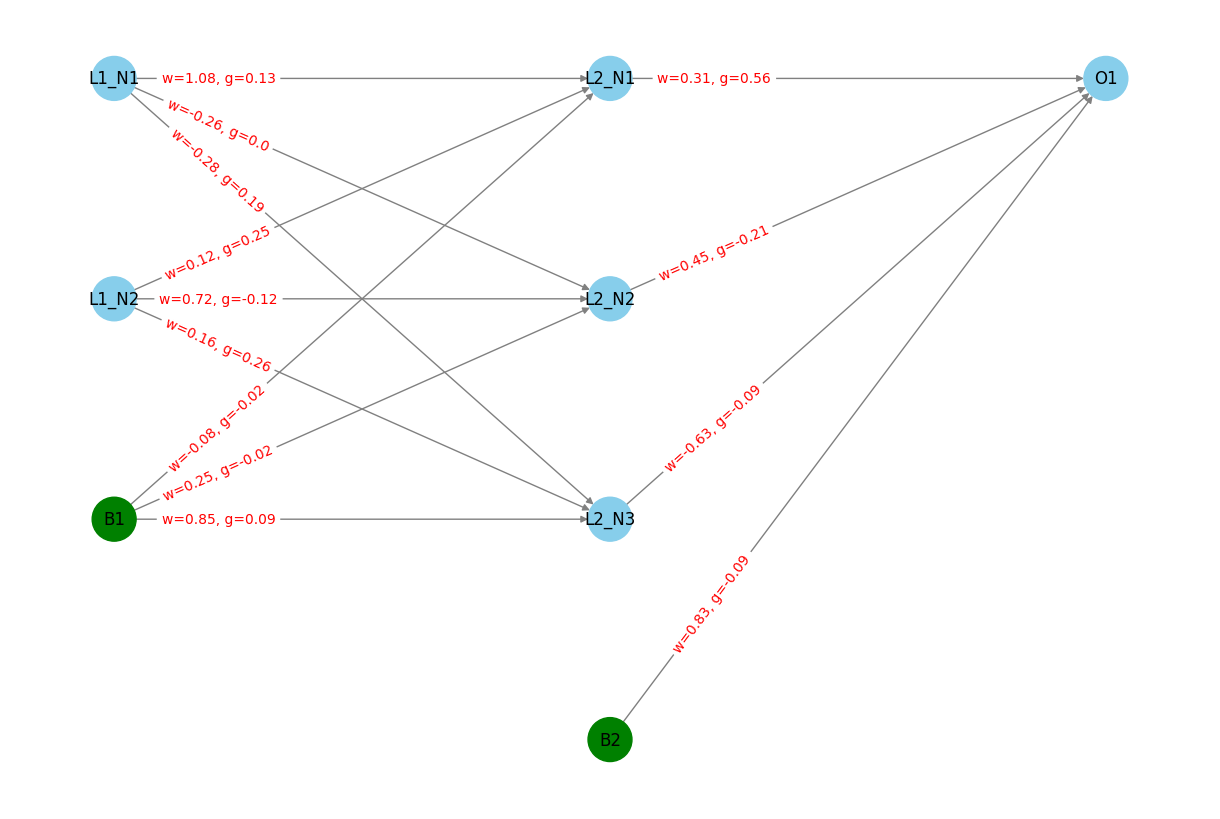

In [39]:
import visualizer
importlib.reload(visualizer)
from visualizer import Visualizer

model = FFNN(
    layer_sizes=[2, 3, 1], 
    activations=['relu', 'linear'], 
    loss_function='mse'
)

history = model.fit(X_train, y_train, epochs=200, batch_size=5, lr=0.001, verbose=0)

visualizer = Visualizer(model)
visualizer.plot_neural_network()